**Building a Siamese Network for the Labelled Faces in the Wild Dataset**

In [2]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset
from torchvision import transforms
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
from PIL import Image

In [36]:
from typing import List, Dict

In [5]:
root_path = "../../data/faces"

In [7]:
label_desc = pd.read_csv(f"{root_path}/Dataset.csv")
label_desc.head(4)

,id,label
0,Robert Downey Jr_87.jpg,Robert Downey Jr
1,Lisa Kudrow_64.jpg,Lisa Kudrow
2,Ellen Degeneres_34.jpg,Ellen Degeneres
3,Billie Eilish_3.jpg,Billie Eilish


In [19]:
label_desc['label'].unique().tolist().index("Robert Downey Jr")

0

In [30]:
# generate all the labels and store them in a list
labels = label_desc['label'].unique().tolist()

In [31]:
label_dict = {k:v for k,v in zip(label_desc['id'].values,label_desc['label'].values)}

visualise some of the images

(160, 160, 3)


(np.float64(-0.5), np.float64(159.5), np.float64(159.5), np.float64(-0.5))

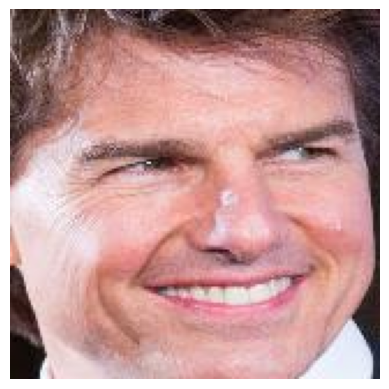

In [14]:
image = Image.open(f"{root_path}/Faces/Faces/Tom Cruise_1.jpg").convert("RGB")
image = np.array(image)
print(image.shape)
plt.imshow(image)
plt.axis("off")

In [15]:
image = Image.open(f"{root_path}/Faces/Faces/Tom Cruise_1.jpg").convert("RGB")
to_tensor = transforms.ToTensor()
image_tensor = to_tensor(image)

In [16]:
image_tensor.shape

torch.Size([3, 160, 160])

Ok, now need to process the datasets to build triplets (for triplet loss training), and pairs (for contrastive loss) training

In [24]:
# since the dataset isn't internally split into training, val, and test sets going to have to do that manually
import random
random.seed(42)
all_files = os.listdir(f"{root_path}/Faces/Faces/")
# shuffling
random.shuffle(all_files)
# splitting
total_files = len(all_files)
train_files = all_files[:int(0.8*total_files)]
val_files = all_files[int(0.8*total_files):int(0.9*total_files)]
test_files = all_files[int(0.9*total_files):]

In [29]:
print(f"Training Instances: {len(train_files)} | Val Instances: {len(val_files)} | Test Instances: {len(test_files)}")

Training Instances: 2049 | Val Instances: 256 | Test Instances: 257


In [101]:
class FacesDataset(Dataset):
    def __init__(self, root_dir: str, files: List[str], labels: List[str], label_dict: Dict[str, str], type:str = 'pair', transforms=None):
        super().__init__()
        self.root_dir = root_dir + "/Faces/Faces"
        self.files = files
        self.transforms = transforms
        self.labels = labels
        self.label_dict = label_dict
        self.type = type

        # building numeric labels
        self.numeric_labels = np.array(list(map(lambda x: self.labels.index(x), self.labels)))

        # for each image in files, need to build/generate a label for it from the labels list so as to have a labels list of numeric type and as long as the files list
        self.numeric_labels_all = np.array(list(map(lambda x: self.labels.index(self.label_dict.get(x)), self.files)))
    
    def __len__(self):
        return len(files)
    
    def __getitem__(self, index):
        if self.type == 'pair':
            pairImages, pairLabels = self.build_pairs()
            if self.transforms:
                a,b = pairImages[index]
                a,b = self.transforms(a), self.transforms(b)
                return (a,b), self.pairLabels[index]
            return pairImages[index], pairLabels[index]
        elif self.type == 'triplet':
            if self.transforms:
                a, p, n = self.build_triplets()[index]
                a, p, n = self.transforms(a), self.transforms(p), self.transforms(n)
                return (a, p, n)
            return self.build_triplets()[index]

    def build_pairs(self):
        # use the numeric labels and images(files) to build the pairs
        pairImages = []
        pairLabels = []

        # for each label in the distinct numeric labels, get the img indices that correspond to that particular label
        similar_img_indices = [np.where(self.numeric_labels_all==label)[0] for label in self.numeric_labels]
        # dissimilar image indices - the opposite of the above, for label, get the indices that do not correspond to that particular label, i.e. the images that aren't that one
        dissimilar_img_indices = [np.where(self.numeric_labels_all != label)[0] for label in self.numeric_labels]

        np.random.seed(42)

        to_tensor = transforms.ToTensor()

        for i, img_path in enumerate(self.files):
            img = Image.open(f"{self.root_dir}/{img_path}")
            img_label = self.numeric_labels_all[i]

            img = to_tensor(img)

            # fetch a similar image
            similar_idx = np.random.choice(similar_img_indices[img_label])
            sim_img = Image.open(f"{self.root_dir}/{self.files[similar_idx]}")
            sim_img = to_tensor(sim_img)


            # fetch a dissimilar image
            dissimilar_idx = np.random.choice(dissimilar_img_indices[img_label])
            dissim_img = Image.open(f"{self.root_dir}/{self.files[dissimilar_idx]}")
            dissim_img = to_tensor(dissim_img)

            pairImages.append((img, sim_img))
            pairLabels.append(1)

            pairImages.append((img, dissim_img))
            pairLabels.append(0)
        return np.array(pairImages), np.array(pairLabels)


    def build_triplets(self):
        # premise for triplets is for each image - as an anchor - get a positive and negative example
        triplets = []

        # for each label in the distinct numeric labels, get the img indices that correspond to that particular label
        similar_img_indices = [np.where(self.numeric_labels_all==label)[0] for label in self.numeric_labels]
        # dissimilar image indices - the opposite of the above, for label, get the indices that do not correspond to that particular label, i.e. the images that aren't that one
        dissimilar_img_indices = [np.where(self.numeric_labels_all != label)[0] for label in self.numeric_labels]

        np.random.seed(42)

        to_tensor = transforms.ToTensor()

        for i, img_path in enumerate(self.files):
            anchor = Image.open(f"{self.root_dir}/{img_path}")
            anchor_label = self.numeric_labels_all[i]

            anchor = to_tensor(anchor)

            # fetch a similar image
            similar_idx = np.random.choice(similar_img_indices[anchor_label])
            sim_img = Image.open(f"{self.root_dir}/{self.files[similar_idx]}")
            sim_img = to_tensor(sim_img)


            # fetch a dissimilar image
            dissimilar_idx = np.random.choice(dissimilar_img_indices[anchor_label])
            dissim_img = Image.open(f"{self.root_dir}/{self.files[dissimilar_idx]}")
            dissim_img = to_tensor(dissim_img)


            triplets.append((anchor, sim_img, dissim_img))
        return np.array(triplets)

Testing the Dataset class

In [102]:
pairs_dataset = FacesDataset(root_dir=root_path, files= train_files, labels=labels, label_dict = label_dict)
triplets_dataset = FacesDataset(root_dir=root_path, files= train_files, labels=labels, label_dict = label_dict, type='triplet')

In [84]:
np.random.seed(42)
query_indices = np.random.choice(np.arange(len(train_files)), size=10)
pairs_examples = pairs_dataset[query_indices.tolist()]
triplets_examples = triplets_dataset[query_indices.tolist()]

In [110]:
pairs_examples[0].shape

(10, 2, 3, 160, 160)

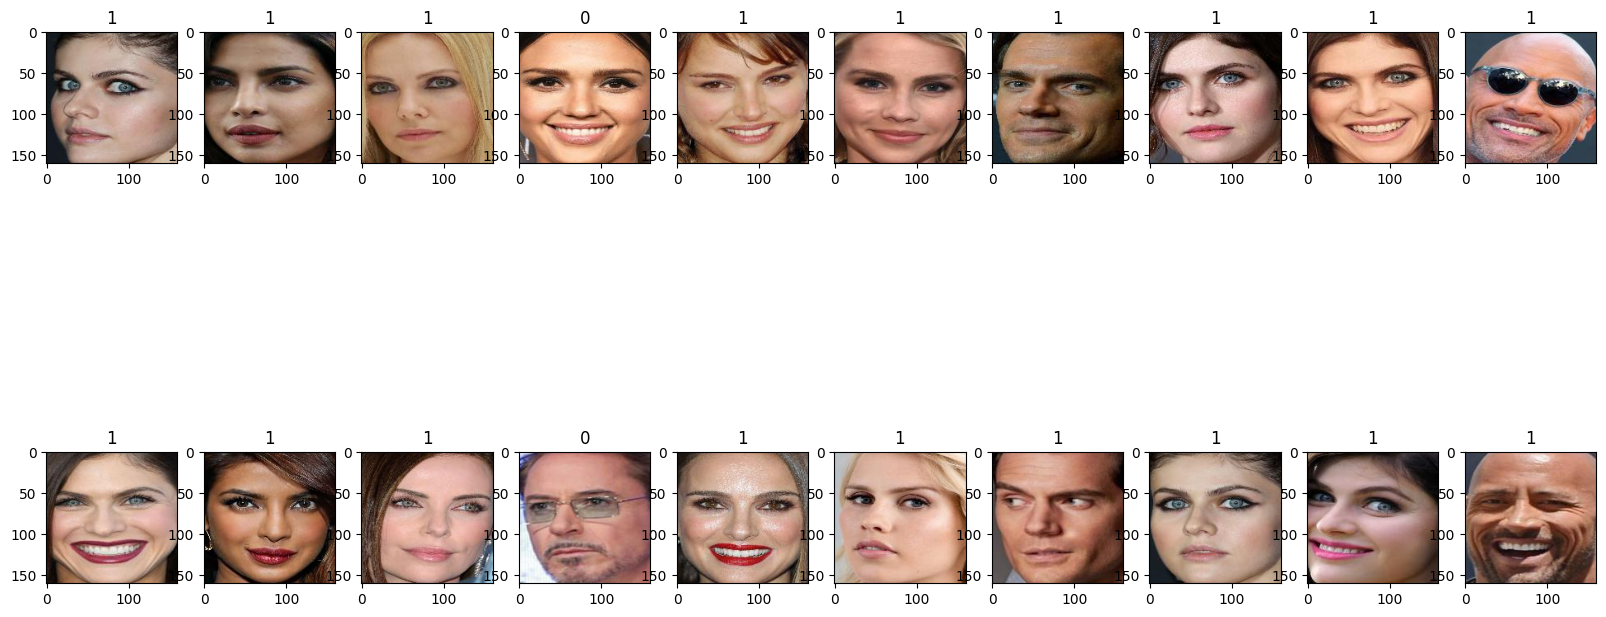

In [114]:
fig, ax = plt.subplots(2,10, figsize=(20,10))

for i in range(2):
    for j in range(10):
        ax[i,j].imshow(pairs_examples[0][j][i].transpose(1,2,0))
        ax[i,j].set_title(pairs_examples[1][j])

In [95]:
pairs_examples[0].shape

(10, 2, 3, 160, 160)

In [100]:
type(pairs_examples[0][0][0])

numpy.ndarray

In [98]:
pairs_examples[1].shape

(10,)

In [79]:
triplets_examples

array([[[[[0.49019608, 0.7647059 , 0.81960785, ..., 0.6509804 ,
           0.7647059 , 0.62352943],
          [0.7176471 , 0.8352941 , 0.8039216 , ..., 0.8784314 ,
           0.92941177, 0.8784314 ],
          [0.8784314 , 0.8745098 , 0.8156863 , ..., 0.85882354,
           0.8784314 , 0.92156863],
          ...,
          [0.00784314, 0.02352941, 0.03529412, ..., 0.7647059 ,
           0.7764706 , 0.8       ],
          [0.01176471, 0.02352941, 0.03137255, ..., 0.7490196 ,
           0.7882353 , 0.84705883],
          [0.00392157, 0.01176471, 0.01176471, ..., 0.827451  ,
           0.85882354, 0.9098039 ]],

         [[0.41960785, 0.69411767, 0.7490196 , ..., 0.56078434,
           0.6862745 , 0.54509807],
          [0.64705884, 0.7647059 , 0.73333335, ..., 0.7882353 ,
           0.8509804 , 0.8       ],
          [0.80784315, 0.8039216 , 0.74509805, ..., 0.78039217,
           0.8       , 0.84313726],
          ...,
          [0.00784314, 0.02352941, 0.03529412, ..., 0.49803922,
    

Text(0.5, 1.0, 'Label: 1')

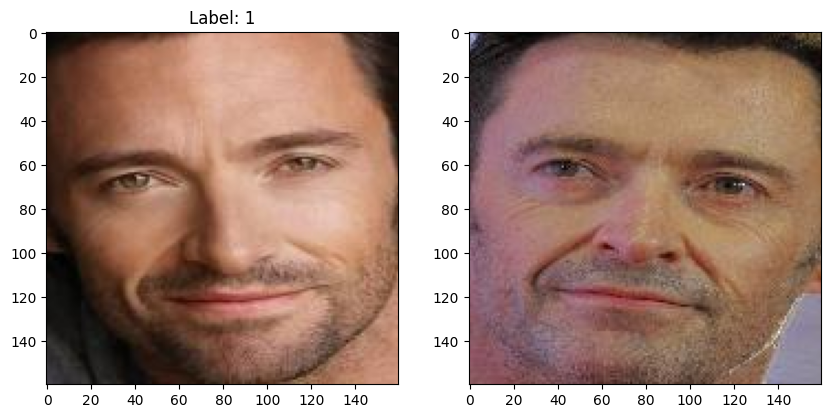

In [62]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

i1, i2 = i
i1 = i1.numpy().transpose(1,2,0)
i2 = i2.numpy().transpose(1,2,0)

ax[0].imshow(i1)
ax[1].imshow(i2)

ax[0].set_title(f"Label: {l}")